# Demo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from model.icrc import InverseConformalRiskControl
from model.creme import CREME
from optimization.lp import LinearProgramming, circle_as_polytope

In [46]:
y_center = np.array([-1.1, -1.])

In [47]:
# Data generation
nsample = 100
y_arr = np.random.uniform(low=-1.0, high=1.0, size=(nsample, 2)) # [ nbatch, nY ]
y_arr = y_arr + y_center

In [48]:
A, b = circle_as_polytope(R=1.0, m=32)
A_pos = np.array([
    [-1., 0.],
    [0., -1.]
])
b_pos = np.array([0., 0.])
A, b = np.concatenate([A, A_pos]), np.concatenate([b, b_pos])

In [49]:
opt_kwds = {
    'A':    A,
    'b':    b,
    'y_center': y_center
}
opt = LinearProgramming(**opt_kwds)

In [50]:
icrc = InverseConformalRiskControl(opt, y_center)

In [84]:
creme_kwds = {
    'y_arr': y_arr,
    'lam_list': np.linspace(0.5, 1., 21),
    'icrc': icrc,
    'output_posthoc': False,
    'w': np.array([1., 1.])
}

regret_hat, miscoverage_hat, lam, F1, F2 = CREME(**creme_kwds)

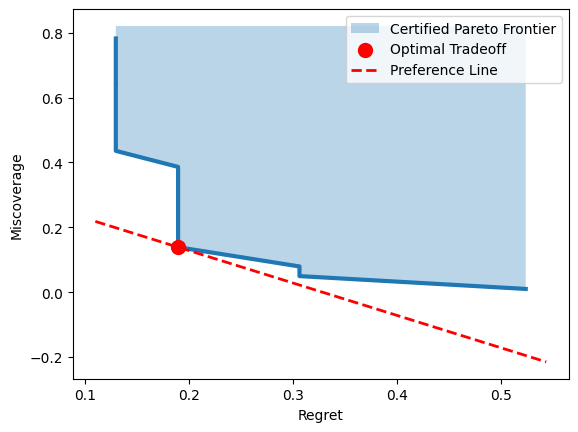

In [86]:
plt.plot(*np.array(F1).T, lw=3)
plt.fill_between(*np.array(F1).T, plt.gca().get_ylim()[1], alpha=0.3, label='Certified Pareto Frontier')
plt.scatter(regret_hat, miscoverage_hat, s=100, c='red', zorder=10, label='Optimal Tradeoff')

x_grid = np.linspace(*plt.gca().get_xlim(), num=100)
slope = -creme_kwds['w'][0] / creme_kwds['w'][1]
y_grid = slope * x_grid + miscoverage_hat - slope * regret_hat
plt.plot(x_grid, y_grid, lw=2, ls='--', c='red', label='Preference Line')

plt.xlabel('Regret')
plt.ylabel('Miscoverage')
plt.legend(loc='upper right')
plt.show()